In [ ]:
import torch
import torch.nn as nn
import numpy as np

import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
class DenseNetwork(nn.Module):
    def __init__(self, layers, num_inputs=2, num_outputs=3):
        super().__init__()

        modules = []
        in_dim = num_inputs
        for h in layers:
            modules.append(nn.Linear(in_dim, h))
            modules.append(nn.Tanh())
            in_dim = h

        modules.append(nn.Linear(in_dim, num_outputs))
        self.net = nn.Sequential(*modules)

        # remove bias and set kaimimng normal with tanh nonlinearity
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="tanh")
                nn.init.zeros_(m.bias)

    def forward(self, xy):
        return self.net(xy)

In [4]:
LAYERS = (64, 64, 64, 64, 64, 64)

p_exit, gamma = 1.4, 0.5
x_throat, delta_throat = 0.5, 0.05
R_in_mult, R_end_mult = 2.0, 1.5
wall_delta = 0.05
# p_in, rho_in, u_in, v_in = 1.0, 1.0, 1.0, 1.0 (dimensionless)

# say, throat is midway, R_in is unit, R_out is 0.75 times that
rad_for_unit_area = 1 / np.sqrt(np.pi)

R_in, R_throat, R_out = (
    R_in_mult * rad_for_unit_area,
    x_throat * rad_for_unit_area,
    R_end_mult * rad_for_unit_area,
)

In [5]:
def generate_rad_space(x):
    x = np.atleast_1d(x)
    radius = np.zeros_like(x)

    # convergent area (till throat)
    radius[x <= x_throat] = R_in - (R_in - R_throat) * (x[x <= x_throat] / x_throat)

    # divergent area (after throat)
    radius[x > x_throat] = R_throat + (R_out - R_throat) * (
        (x[x > x_throat] - x_throat) / (1 - x_throat)
    )
    return radius


def generate_nozzle_points(
    N_interior=1000,
    N_inlet=100,
    N_outlet=100,
    N_wall=150,
    N_throat_wall=50,
    N_center=150,
):
    inlet_pts = torch.tensor(
        np.hstack([np.zeros((N_inlet, 1)), np.linspace(0, R_in, N_inlet)[:, None]]),
        dtype=torch.float32,
        requires_grad=True,
        device=device,
    )

    outlet_pts = torch.tensor(
        np.hstack([np.ones((N_outlet, 1)), np.linspace(0, R_out, N_outlet)[:, None]]),
        dtype=torch.float32,
        requires_grad=True,
        device=device,
    )

    center_pts = torch.tensor(
        np.hstack([np.linspace(0, 1, N_center)[:, None], np.zeros((N_center, 1))]),
        dtype=torch.float32,
        requires_grad=True,
        device=device,
    )

    wall_x = np.linspace(0, 1, N_wall)
    wall_pts = torch.tensor(
        np.hstack([wall_x[:, None], generate_rad_space(wall_x)[:, None]]),
        dtype=torch.float32,
        requires_grad=True,
        device=device,
    )

    throat_wall_x = np.linspace(
        x_throat - delta_throat, x_throat + delta_throat, N_throat_wall
    )
    throat_wall_pts = torch.tensor(
        np.hstack([throat_wall_x[:, None], generate_rad_space(throat_wall_x)[:, None]]),
        dtype=torch.float32,
        requires_grad=True,
        device=device,
    )

    random_interior_pts = np.random.rand(N_interior, 2)  # double, then filter
    wall_limits = generate_rad_space(random_interior_pts[:, 0])
    interior_pts = torch.tensor(
        np.hstack(
            [
                random_interior_pts[:, 0][:, None],
                random_interior_pts[:, 1] * wall_limits[:, None],
            ]
        ),
        dtype=torch.float32,
        requires_grad=True,
        device=device,
    )

    return [*interior_pts, *inlet_pts, *outlet_pts, *wall_pts, *throat_wall_pts, *center_pts]

In [12]:
def d_(f, x):
    return torch.autograd.grad(
        f, x, grad_outputs=torch.ones_like(f), create_graph=True
    )[0]

def model_grads(model, xy):
    out = model(xy)
    psi = out[:, :1]
    p = out[:, 1:2]
    rho = out[:, 2:3]

    x = xy[:, :1]
    y = xy[:, 1:2]
    y_x = d_(y, x)

    grad_psi = d_(psi, xy)
    u = grad_psi[:, 1:2]
    v = -grad_psi[:, 0:1]

    u_y = d_(u, y)
    rho_y = d_(rho, y)

    rho1u1 = rho * u
    rho1v1 = rho * v
    rho1u1_x = d_(rho1u1, x)
    rho1v1_y = d_(rho1v1, y)

    rho1u2 = rho1u1 * u
    rho1v2 = rho1v1 * v
    rho1u2_x = d_(rho1u2, x)
    rho1v2_y = d_(rho1v2, y)

    rho1u1v1 = rho1u1 * v
    grad_rho1u1v1 = d_(rho1u1v1, xy)
    rho1u1v1_x = grad_rho1u1v1[:, :1]
    rho1u1v1_y = grad_rho1u1v1[:, 1:2]

    grad_p = d_(p, xy)
    p_x = grad_p[:, :1]
    p_y = grad_p[:, 1:2]

    avg_rho1u2v2 = (rho1u2 + rho1v2) / 2
    u1avg_rho1u2v2 = u * avg_rho1u2v2
    v1avg_rho1u2v2 = v * avg_rho1u2v2
    u1avg_rho1u2v2_x = d_(u1avg_rho1u2v2, x)
    v1avg_rho1u2v2_y = d_(v1avg_rho1u2v2, y)

    u1p1 = u * p
    v1p1 = v * p
    u1p1_x = d_(u1p1, x)
    v1p1_y = d_(v1p1, y)

    return {
        "xy": xy,
        "y_x": y_x,
        "u": u,
        "u_y": u_y,
        "v": v,
        "p": p,
        "rho": rho,
        "rho_y": rho_y,
        "rho1u1_x": rho1u1_x,
        "rho1v1_y": rho1v1_y,
        "rho1u2_x": rho1u2_x,
        "rho1v2_y": rho1v2_y,
        "rho1u1v1_x": rho1u1v1_x,
        "rho1u1v1_y": rho1u1v1_y,
        "p_x": p_x,
        "p_y": p_y,
        "u1avg_rho1u2v2_x": u1avg_rho1u2v2_x,
        "v1avg_rho1u2v2_y": v1avg_rho1u2v2_y,
        "u1p1_x": u1p1_x,
        "v1p1_y": v1p1_y
    }

In [7]:
def pde_residuals(fields, gamma=1.4):
    rho1u1_x, rho1v1_y = fields["rho1u1_x"], fields["rho1v1_y"]
    rho1u2_x, rho1v2_y = fields["rho1u2_x"], fields["rho1v2_y"]
    rho1u1v1_x, rho1u1v1_y = fields["rho1u1v1_x"], fields["rho1u1v1_y"]
    p_x, p_y = fields["p_x"], fields["p_y"]
    u1p1_x, v1p1_y = fields["u1p1_x"], fields["v1p1_y"]
    u1avg_rho1u2v2_x, v1avg_rho1u2v2_y = (
        fields["u1avg_rho1u2v2_x"],
        fields["v1avg_rho1u2v2_y"],
    )

    mass = rho1u1_x + rho1v1_y
    mom_x = rho1u2_x + p_x + rho1u1v1_y
    mom_y = rho1u1v1_x + p_y + rho1v2_y
    energy = (
        (gamma / (gamma - 1)) * (u1p1_x + v1p1_y) + u1avg_rho1u2v2_x + v1avg_rho1u2v2_y
    )

    return mass, mom_x, mom_y, energy


def inlet_bd_residuals(fields):
    def filter_bd(arr, mask):
        arr = arr[mask]
        return 1.0 - arr

    xy, u, v, p, rho = (
        fields["xy"],
        fields["u"],
        fields["v"],
        fields["p"],
        fields["rho"],
    )

    # filter the predictions here that are on the inlet boundary
    inlet_mask = xy[:, 0:1] == 0.0
    u_inlet, p_inlet, rho_inlet = map(
        lambda arr: filter_bd(arr, inlet_mask), [u, p, rho]
    )
    return u_inlet, v[inlet_mask], p_inlet, rho_inlet


def wall_bd_residuals(fields):
    xy, y_x, u, v = fields["xy"], fields["y_x"], fields["u"], fields["v"]

    wall_mask = xy[:, 1:2] >= generate_rad_space(xy[:, 0:1]) - wall_delta
    u_wall, v_wall, y_x_wall = u[wall_mask], v[wall_mask], y_x[wall_mask]

    return v_wall - u_wall * y_x_wall


def center_bd_residuals(fields):
    xy, v, u_y, p_y, rho_y = (
        fields["xy"],
        fields["v"],
        fields["u_y"],
        fields["p_y"],
        fields["rho_y"],
    )

    center_mask = xy[:, 1:2] == 0.0
    v_center, u_y_center, p_y_center, rho_y_center = (
        v[center_mask],
        u_y[center_mask],
        p_y[center_mask],
        rho_y[center_mask],
    )

    return v_center, u_y_center, p_y_center, rho_y_center

def exit_bd_residuals(fields):
    xy, p = fields["xy"], fields["p"]

    outlet_mask = xy[:, 0:1] == 1.0
    p_outlet = p[outlet_mask]

    return p_outlet - p_exit

In [8]:
def compute_loss(outputs, gamma=1.4):
    mass, mom_x, mom_y, energy = pde_residuals(outputs, gamma)
    inlet_u, inlet_v, inlet_p, inlet_rho = inlet_bd_residuals(outputs)
    center_v, center_u_y, center_p_y, center_rho_y = center_bd_residuals(outputs)
    wall_v = wall_bd_residuals(outputs)
    outlet_p = exit_bd_residuals(outputs)

    pde_loss = torch.mean(mass**2 + mom_x**2 + mom_y**2 + energy**2)
    inlet_loss = torch.mean(inlet_u**2 + inlet_v**2 + inlet_p**2 + inlet_rho**2)
    center_loss = torch.mean(center_v**2 + center_u_y**2 + center_p_y**2 + center_rho_y**2)
    wall_loss = torch.mean(wall_v**2)
    outlet_loss = torch.mean(outlet_p**2)

    total_loss = pde_loss + inlet_loss + center_loss + wall_loss + outlet_loss
    return total_loss, pde_loss, inlet_loss, center_loss, wall_loss, outlet_loss

In [9]:
from typing import Optional
from pathlib import Path
from datetime import datetime
from copy import deepcopy
import os


class ModelSave:
    SAVE_DIR_NAME = "saved_models_pinn"

    def __init__(self):
        file = os.path.dirname(os.path.abspath("__file__"))
        self.save_dir = Path(file).joinpath(self.SAVE_DIR_NAME)
        self.save_dir.mkdir(exist_ok=True)

    def generate_save_path(self, suffix: Optional[str] = None) -> str:
        timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        model_name = f"hybrid-qpinn-v2-{timestamp}"
        if suffix:
            model_name += f"-{suffix}"
        return str(self.save_dir.joinpath(model_name + ".pt"))

    @staticmethod
    def snapshot(model: nn.Module):
        return deepcopy(model.state_dict())

    @staticmethod
    def restore(model: nn.Module, snapshot: dict):
        model.load_state_dict(snapshot)

    @staticmethod
    def update_best(
        model: nn.Module,
        current_loss: float,
        best_loss: Optional[float],
        best_snapshot: Optional[dict],
    ):
        if best_loss is None or current_loss < best_loss:
            return current_loss, ModelSave.snapshot(model)
        return best_loss, best_snapshot

    @staticmethod
    def save(model: nn.Module, path: str):
        model_state = ModelSave.snapshot(model)

        torch.save(model_state, path)
        print(f"Model saved to {path}")

    @staticmethod
    def load(path: str):
        if not os.path.exists(path):
            raise FileNotFoundError(f"No model found at {path}")

        model = DenseNetwork(layers=LAYERS).to(device)
        model_state = torch.load(path, map_location=device)
        ModelSave.restore(model, model_state)
        print(f"Model loaded from {path}")
        return model

In [ ]:
def train(
    model,
    gamma=1.4,
    adam_iters=3000,
    lbfgs_iters=1000,
    adam_lr=1e-3,
    model_manager=ModelSave(),
    print_every=250,
):
    best_loss, best_state = float("inf"), None
    history = []

    adam = torch.optim.Adam(model.parameters(), lr=adam_lr)
    print("Starting Adam...")
    points = generate_nozzle_points()

    for i in range(adam_iters):
        adam.zero_grad()

        outputs = model_grads(model, points)
        total_loss, pde_loss, inlet_loss, center_loss, wall_loss, outlet_loss = (
            compute_loss(outputs, gamma)
        )

        best_loss, best_state = model_manager.update_best(
            model, total_loss.item(), best_loss, best_state
        )

        total_loss.backward()
        adam.step()

        if (i + 1) % print_every == 0:
            print(
                f"Adam Iter {i+1}/{adam_iters}, Total Loss: {total_loss.item():.4e}, PDE Loss: {pde_loss.item():.4e}, Inlet Loss: {inlet_loss.item():.4e}, Center Loss: {center_loss.item():.4e}, Wall Loss: {wall_loss.item():.4e}, Outlet Loss: {outlet_loss.item():.4e}"
            )
            history.append(
                (
                    total_loss.item(),
                    pde_loss.item(),
                    inlet_loss.item(),
                    center_loss.item(),
                    wall_loss.item(),
                    outlet_loss.item(),
                )
            )

    if best_state is not None:
        model_manager.restore(model, best_state)
    print("[Adam] Optimizer ran.", end=" ")
    save_path = model_manager.generate_save_path(suffix="post-adam")
    model_manager.save(model, save_path)
    print(f"[Adam] Model saved to {save_path}.")

    params = [p for p in model.parameters() if p.requires_grad]
    lbfgs = torch.optim.lbfgs(
        params, max_iter=lbfgs_iters, line_search_fn="strong_wolfe"
    )

    def lbfgs_closure():
        model.zero_grad()
        outputs = model_grads(model, points)
        total_loss, _, _, _, _, _ = compute_loss(outputs, gamma)
        total_loss.backward()
        return total_loss

    for i in range(lbfgs_iters):
        total_loss = lbfgs.step(lbfgs_closure)
        loss_value = float(total_loss.detach().item())
        best_loss, best_state = ModelSave.update_best(
            model, loss_value, best_loss, best_state
        )

        history.append((loss_value,))
        if (i + 1) % print_every == 0:
            print(f"L-BFGS Iter {i+1}/{lbfgs_iters}, Total Loss: {loss_value:.4e}")

    if best_state is not None:
        model_manager.restore(model, best_state)
    print("[L-BFGS] Optimizer ran.", end=" ")
    save_path = model_manager.generate_save_path(suffix="post-lbfgs")
    model_manager.save(model, save_path)
    print(f"[L-BFGS] Model saved to {save_path}.")

    return history

In [10]:
model = DenseNetwork(layers=LAYERS).to(device)

{
    "total params": sum(p.numel() for p in model.parameters()),
    "trainable params": sum(p.numel() for p in model.parameters() if p.requires_grad),
}

{'total params': 21187, 'trainable params': 21187}

In [ ]:
loss_history = train(model, gamma=gamma)

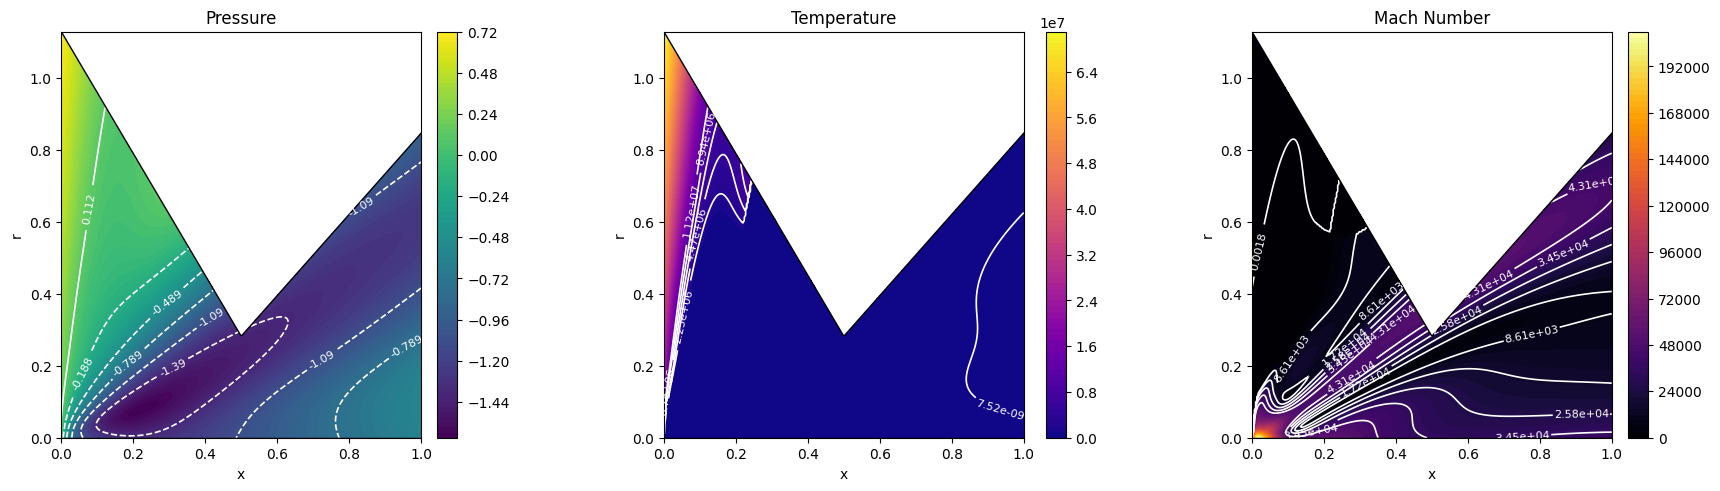

In [ ]:
model.eval()

Nx, Ny = 320, 220
x_vals = np.linspace(0.0, 1.0, Nx)
y_vals = np.linspace(0.0, max(R_in, R_out), Ny)
X, Y = np.meshgrid(x_vals, y_vals)

R_wall = generate_rad_space(X)
inside_mask = Y <= R_wall

xy_inside = np.column_stack((X[inside_mask], Y[inside_mask]))
xy_inside_t = torch.tensor(
    xy_inside, dtype=torch.float32, device=device, requires_grad=True
)

pred = model(xy_inside_t)
psi = pred[:, :1]
p = pred[:, 1:2]
rho = pred[:, 2:3]

grad_psi = torch.autograd.grad(
    psi,
    xy_inside_t,
    grad_outputs=torch.ones_like(psi),
    create_graph=False,
    retain_graph=False,
)[0]

u = grad_psi[:, 1:2]
v = -grad_psi[:, 0:1]

p_np = p.detach().cpu().numpy().ravel()
rho_np = rho.detach().cpu().numpy().ravel()
u_np = u.detach().cpu().numpy().ravel()
v_np = v.detach().cpu().numpy().ravel()

rho_safe = np.clip(rho_np, 1e-8, None)
p_safe = np.clip(p_np, 1e-8, None)
T_np = p_safe / rho_safe
vel_mag = np.sqrt(u_np**2 + v_np**2)
a_np = np.sqrt(np.clip(gamma * p_safe / rho_safe, 1e-12, None))
M_np = vel_mag / a_np

P_grid = np.full_like(X, np.nan, dtype=float)
T_grid = np.full_like(X, np.nan, dtype=float)
M_grid = np.full_like(X, np.nan, dtype=float)

P_grid[inside_mask] = p_np
T_grid[inside_mask] = T_np
M_grid[inside_mask] = M_np

fig, axs = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)
plots = [
    (P_grid, "Pressure", "viridis"),
    (T_grid, "Temperature", "plasma"),
    (M_grid, "Mach Number", "inferno"),
]

# Set exact contour levels if you want fixed values for a field.
# Example: specific_levels["Mach Number"] = [0.2, 0.4, 0.6, 0.8, 1.0]
specific_levels = {
    "Pressure": [-1.4, -1.0, -0.6, -0.2, 0.2],
    "Temperature": [0.2, 0.5, 1.0, 2.0, 4.0],
    "Mach Number": [0.2, 0.5, 0.8, 1.0, 1.2],
}

wall_profile = generate_rad_space(x_vals)
for ax, (field, title, cmap) in zip(axs, plots):
    contour = ax.contourf(X, Y, field, levels=80, cmap=cmap)

    valid = field[np.isfinite(field)]
    if specific_levels[title] is None:
        # Distinct internal levels avoid min/max noise and draw clearer isolines.
        level_min, level_max = np.percentile(valid, [10, 90])
        line_levels = np.linspace(level_min, level_max, 6)
    else:
        line_levels = np.array(specific_levels[title], dtype=float)

    lines = ax.contour(X, Y, field, levels=line_levels, colors="white", linewidths=1.2)
    ax.clabel(lines, inline=True, fmt="%.3g", fontsize=8)

    ax.plot(x_vals, wall_profile, color="black", lw=1.0)
    ax.plot(x_vals, np.zeros_like(x_vals), color="black", lw=1.0)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("r")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, max(R_in, R_out))
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(contour, ax=ax, pad=0.01)

plt.show()